<a href="https://colab.research.google.com/github/ting-150/IF_AUS/blob/main/%E5%9C%8B%E9%9A%9B%E9%87%91%E8%9E%8D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **雙邊匯率資料分析-AUD/USD WK4-WK13**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 有 CSV 檔案，裡面有列：Date, Price, Open, High, Low, Change%
data = pd.read_csv('/content/AUD_USD Historical Data.csv', parse_dates=['Date'])

# 查看資料
print(data.head())

        Date   Price    Open    High     Low  Vol. Change %
0 2025-11-09  0.6537  0.6492  0.6582  0.6488   NaN    0.66%
1 2025-11-02  0.6494  0.6548  0.6563  0.6458   NaN   -0.79%
2 2025-10-26  0.6546  0.6526  0.6619  0.6525   NaN    0.49%
3 2025-10-19  0.6514  0.6483  0.6531  0.6472   NaN    0.26%
4 2025-10-12  0.6497  0.6503  0.6534  0.6440   NaN    0.39%


In [ ]:
# 將 Change % 轉成數值型態
data['Change_pct'] = data['Change %'].str.replace('%','').astype(float)

# 計算每週波動幅度 (High - Low)
data['Range'] = data['High'] - data['Low']

# 判斷每週升值或貶值 (Price 相對上週)
data['Trend'] = data['Price'].diff()
data['Trend_label'] = data['Trend'].apply(lambda x: 'Appreciation' if x>0 else ('Depreciation' if x<0 else 'Flat'))

# 排序日期
data = data.sort_values('Date', ascending=True).reset_index(drop=True)

# 設定 Week 標籤（假設從 WK3 開始）
data['Week'] = ['WK'+str(i+3) for i in range(len(data))]

# 設定 Week 為 index
data.set_index('Week', inplace=True)

# 顯示統計資料
print("Weekly Exchange Rate Statistics:")
print(data[['Date','Price','High','Low','Range','Change_pct','Trend_label']])

Weekly Exchange Rate Statistics:
           Date   Price    High     Low   Range  Change_pct   Trend_label
Week                                                                     
WK3  2025-09-28  0.6604  0.6630  0.6545  0.0085        0.89  Appreciation
WK4  2025-10-05  0.6472  0.6626  0.6472  0.0154       -2.00  Depreciation
WK5  2025-10-12  0.6497  0.6534  0.6440  0.0094        0.39  Depreciation
WK6  2025-10-19  0.6514  0.6531  0.6472  0.0059        0.26  Depreciation
WK7  2025-10-26  0.6546  0.6619  0.6525  0.0094        0.49  Appreciation
WK8  2025-11-02  0.6494  0.6563  0.6458  0.0105       -0.79  Depreciation
WK9  2025-11-09  0.6537  0.6582  0.6488  0.0094        0.66          Flat


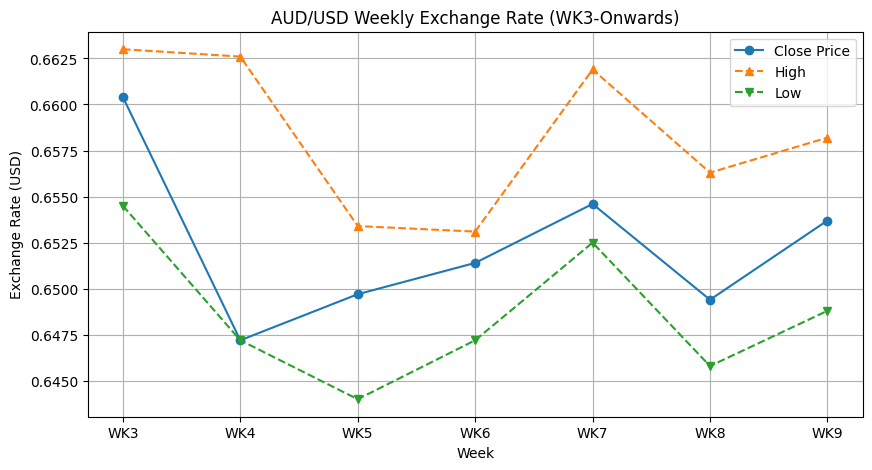


Weekly Trend Analysis:
WK3 (2025-09-28): Close Price 0.6604, Range 0.0085, Change 0.89%, Trend Appreciation
WK4 (2025-10-05): Close Price 0.6472, Range 0.0154, Change -2.0%, Trend Depreciation
WK5 (2025-10-12): Close Price 0.6497, Range 0.0094, Change 0.39%, Trend Depreciation
WK6 (2025-10-19): Close Price 0.6514, Range 0.0059, Change 0.26%, Trend Depreciation
WK7 (2025-10-26): Close Price 0.6546, Range 0.0094, Change 0.49%, Trend Appreciation
WK8 (2025-11-02): Close Price 0.6494, Range 0.0105, Change -0.79%, Trend Depreciation
WK9 (2025-11-09): Close Price 0.6537, Range 0.0094, Change 0.66%, Trend Flat


In [ ]:
# 繪製 Price, High, Low 走勢圖
plt.figure(figsize=(10,5))
plt.plot(data.index, data['Price'], marker='o', label='Close Price')
plt.plot(data.index, data['High'], marker='^', linestyle='--', label='High')
plt.plot(data.index, data['Low'], marker='v', linestyle='--', label='Low')
plt.title('AUD/USD Weekly Exchange Rate (WK3-Onwards)')
plt.xlabel('Week')
plt.ylabel('Exchange Rate (USD)')
plt.grid(True)
plt.legend()
plt.show()

# 每週趨勢分析輸出
print("\nWeekly Trend Analysis:")
for week in data.index:
    row = data.loc[week]
    print(f"{week} ({row['Date'].date()}): Close Price {row['Price']}, Range {row['Range']:.4f}, Change {row['Change_pct']}%, Trend {row['Trend_label']}")


# **未來雙邊匯率模型預測-AUD/USD**

# 套件匯入

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 讀取資料

In [ ]:
data = pd.read_csv('/content/AUDUSD_Monthly_2000.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# 月資料 → 設定為每個月頻率，並線性補齊缺缺值
data = data.asfreq('M')
data['AUD_USD'] = data['AUD_USD'].interpolate(method='linear')

/tmp/ipython-input-3649950762.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.asfreq('M')


# ACF / PACF（模型判別參考）

<Figure size 1000x400 with 0 Axes>

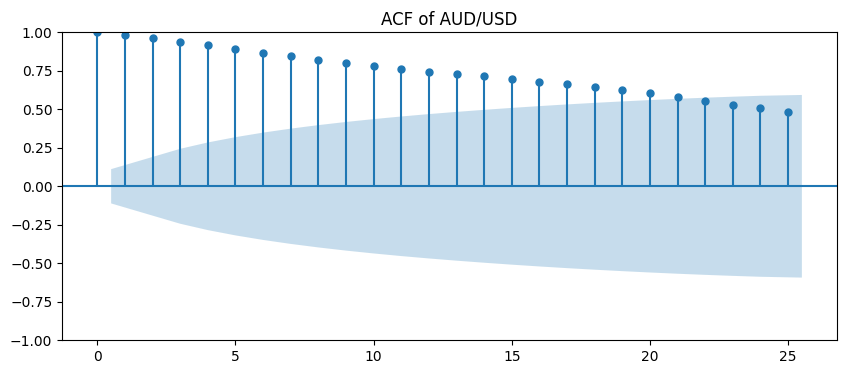

<Figure size 1000x400 with 0 Axes>

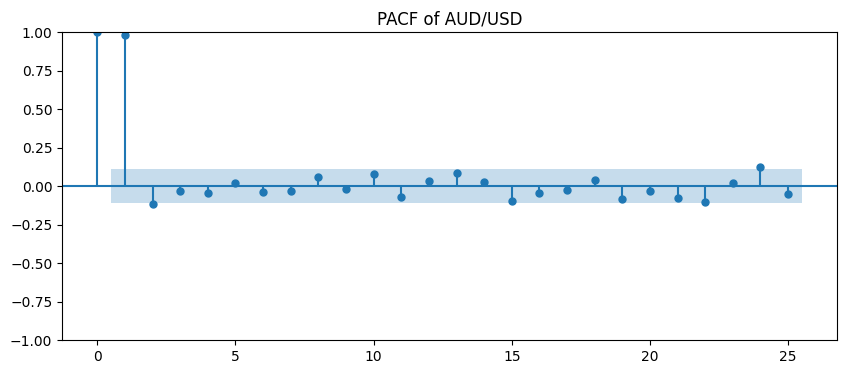

In [ ]:
plt.figure(figsize=(10,4))
plot_acf(data['AUD_USD'])
plt.title("ACF of AUD/USD")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(data['AUD_USD'])
plt.title("PACF of AUD/USD")
plt.show()

圖一（ACF）分析：


Lag 0–20 的棒子都超過藍色底，顯著。


Lag 20–25 的棒子落入藍色底，不顯著。


Lag 0 的棒子必然為 1。


棒子隨著 lag 增加逐漸下降，呈現拖尾（tailing off），即慢慢下降而非突然截尾，顯示資料可能存在趨勢或非平穩性。


大部分 lag 都顯著，表示歷史影響力較長（長記憶）。


解讀：


ACF 顯示序列值與滯後值的相關性，ACF 衰減緩慢是非平穩序列（Non-Stationary Series）的典型特徵。


AUD/USD 匯率序列可能具有趨勢或單根。



圖二（PACF）分析：


Lag 1 的棒子顯著超出藍色底，Lag 0 為 1（完全相關）。


Lag 2–25 幾乎落入藍色底，不顯著。


唯一例外：Lag 22 約 0.2，影響很小，可忽略。


PACF 呈截尾（cut-off）現象：Lag 1 後快速落入置信區間，AR 成分主要集中在前期。


解讀：


PACF 顯示序列值與滯後值之間的直接相關性，排除中間滯後的間接影響。


當前值主要受前一期值直接影響，序列依賴性集中於 Lag 1。




# 訓練集 / 驗證集切分

In [ ]:
train = data[:'2024-12-31']
valid = data['2025-01-31':]

results = {}   # 存放各模型 RMSE 與預測

# ARIMA 模型

In [ ]:
print("Fitting ARIMA model...")

arima_auto = auto_arima(
    train['AUD_USD'],
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    max_p=5, max_q=5
)

best_order = arima_auto.order
print("Best ARIMA order:", best_order)

# 正式建立 ARIMA 模型（使用 statespace 提升穩定性）
model_arima = ARIMA(train['AUD_USD'], order=best_order).fit(method='statespace')

# 驗證集預測
pred_arima = model_arima.forecast(steps=len(valid))

rmse_arima = np.sqrt(mean_squared_error(valid['AUD_USD'], pred_arima))
results['ARIMA'] = {'model': model_arima, 'rmse': rmse_arima, 'pred': pred_arima}

print("ARIMA RMSE:", rmse_arima)

Fitting ARIMA model...
Best ARIMA order: (0, 1, 0)
ARIMA RMSE: 0.025495396643315817


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# ETS（指數平滑）

In [ ]:
print("Fitting ETS model...")

ets_model = ExponentialSmoothing(train['AUD_USD'], trend='add', seasonal=None).fit()
pred_ets = ets_model.forecast(len(valid))

rmse_ets = np.sqrt(mean_squared_error(valid['AUD_USD'], pred_ets))
results['ETS'] = {'model': ets_model, 'rmse': rmse_ets, 'pred': pred_ets}

print("ETS RMSE:", rmse_ets)

Fitting ETS model...
ETS RMSE: 0.025829557305422843


# Naive（隨機漫步）

In [ ]:
naive_pred = pd.Series(train['AUD_USD'].iloc[-1], index=valid.index)
rmse_naive = np.sqrt(mean_squared_error(valid['AUD_USD'], naive_pred))

results['Naive'] = {'model': 'Naive', 'rmse': rmse_naive, 'pred': naive_pred}

print("Naive RMSE:", rmse_naive)

Naive RMSE: 0.025495396643315817


# Seasonal Naive（去年同月）

In [ ]:
snaive_pred = pd.Series(
    train['AUD_USD'][-12:].values[:len(valid)],
    index=valid.index
)

rmse_snaive = np.sqrt(mean_squared_error(valid['AUD_USD'], snaive_pred))

results['SNaive'] = {'model': 'SNaive', 'rmse': rmse_snaive, 'pred': snaive_pred}

print("SNaive RMSE:", rmse_snaive)

SNaive RMSE: 0.02121006836386908


# 比較 RMSE → 選最佳模型

In [ ]:
best_model_name = min(results, key=lambda x: results[x]['rmse'])
best_model_info = results[best_model_name]

print(f"最佳模型：{best_model_name}")
print(f"RMSE：{best_model_info['rmse']:.6f}")

最佳模型：SNaive
RMSE：0.021210


# 未來多步預測

In [ ]:
forecast_steps = 12   # 你可自己改預測未來期數

last_date = data.index[-1]
future_index = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=forecast_steps, freq='M')

# 依據最佳模型預測未來
if best_model_name == 'ARIMA':
    future_forecast = best_model_info['model'].forecast(steps=forecast_steps)

elif best_model_name == 'ETS':
    future_forecast = best_model_info['model'].forecast(forecast_steps)

elif best_model_name == 'Naive':
    future_forecast = pd.Series(train['AUD_USD'].iloc[-1], index=future_index)

elif best_model_name == 'SNaive':
    future_forecast = pd.Series(train['AUD_USD'][-12:].values[:forecast_steps],
                                index=future_index)

/tmp/ipython-input-4104669489.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),


# 歷史 + 未來預測

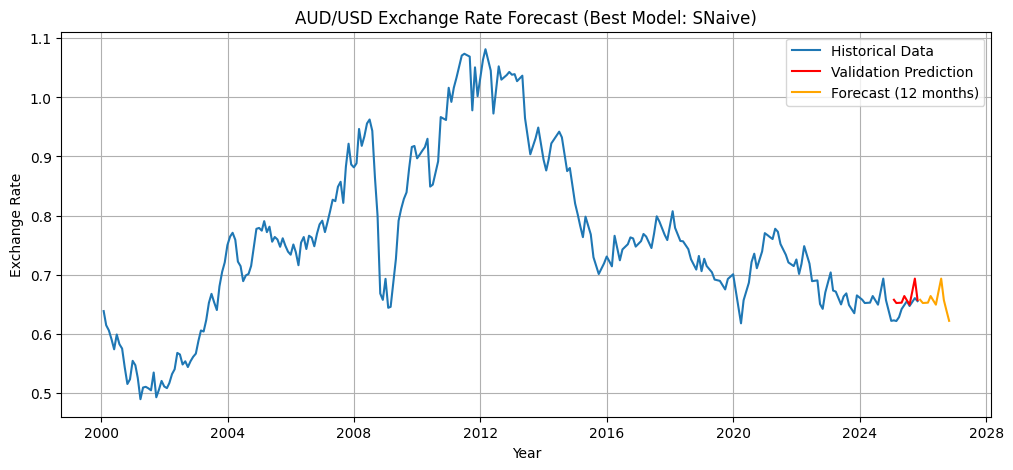

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data['AUD_USD'], label='Historical Data')
plt.plot(valid.index, best_model_info['pred'], color='red', label='Validation Prediction')
plt.plot(future_forecast.index, future_forecast, label=f'Forecast ({forecast_steps} months)', color='orange')

plt.title(f'AUD/USD Exchange Rate Forecast (Best Model: {best_model_name})')
plt.xlabel('Year')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.legend()
plt.show()

## **經常帳GDP佔比對匯率**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/2000.csv')

# 查看資料
print(data.head())

         Date   Price    Open    High     Low  Vol. Change %
0  11/01/2025  0.6432  0.6545  0.6581  0.6423   NaN   -1.74%
1  10/01/2025  0.6546  0.6613  0.6630  0.6440   NaN   -1.03%
2  09/01/2025  0.6614  0.6538  0.6708  0.6483   NaN    1.12%
3  08/01/2025  0.6541  0.6426  0.6570  0.6414   NaN    1.79%
4  07/01/2025  0.6426  0.6577  0.6626  0.6424   NaN   -2.36%


In [ ]:
import pandas as pd

df = pd.read_csv('/content/current.csv')

# 保留第二行（index=1），因為它才是真正的資料列
row = df.iloc[1]

# 轉成 long format
data_current = pd.DataFrame({
    "Year": row.index[1:],      # 去掉第一欄名稱欄
    "Value": row.values[1:]
})

# 把 Year 轉數字，把 Value 轉 float
data_current["Year"] = data_current["Year"].astype(int)
data_current["Value"] = pd.to_numeric(data_current["Value"], errors='coerce')

print(data_current.head())

   Year  Value
0  2000   -4.0
1  2001   -2.2
2  2002   -3.8
3  2003   -5.3
4  2004   -6.3


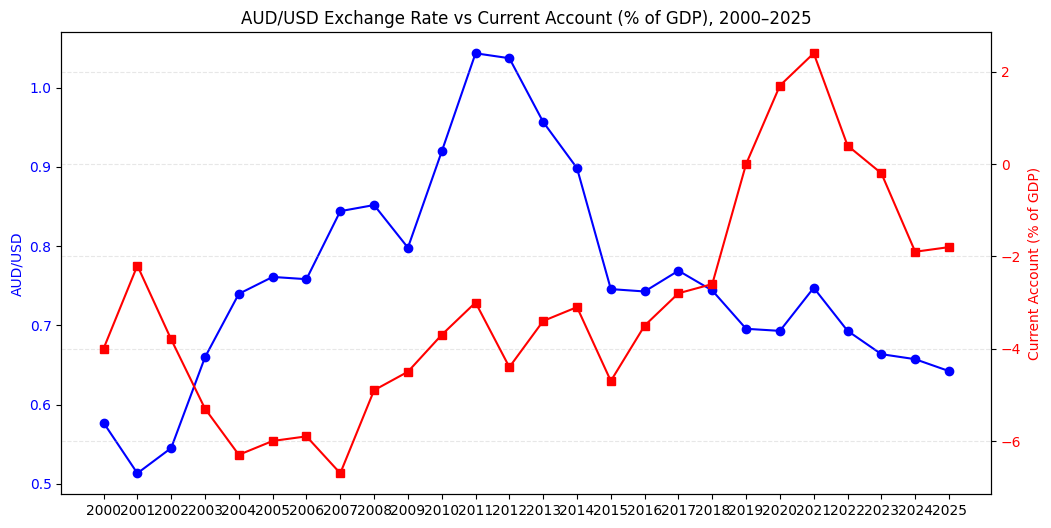

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# 讀取 AUD/USD 匯率資料（2000.csv）
# ======================================
fx = pd.read_csv('/content/2000.csv')

# 修改日期格式（你的日期是 "MM/DD/YYYY"）
fx['Date'] = pd.to_datetime(fx['Date'], format="%m/%d/%Y")

# 取 Price（匯率）
fx = fx[['Date', 'Price']].sort_values('Date')

# 取年份欄（方便跟經常帳資料對齊）
fx['Year'] = fx['Date'].dt.year

# ======================================
# 讀取 Current Account (% of GDP)
# ======================================
df = pd.read_csv('/content/current.csv')

row = df.iloc[1]  # 第二列才是真正數據

data_current = pd.DataFrame({
    "Year": row.index[1:],
    "Value": row.values[1:]
})

data_current["Year"] = data_current["Year"].astype(int)
data_current["Value"] = pd.to_numeric(data_current["Value"], errors='coerce')
data_current = data_current.dropna()

# ======================================
# 合併年份，以確保 X 軸一致（2000–2025）
# ======================================
years = list(range(2000, 2026))

# 每年平均匯率（因為匯率是月資料）
fx_yearly = fx.groupby("Year")["Price"].mean().reindex(years)

# 經常帳資料對齊
ca_yearly = data_current.set_index("Year")["Value"].reindex(years)

# ======================================
# 畫圖：左右雙軸，同一 X 軸（2000–2025）
# ======================================
plt.figure(figsize=(12, 6))

ax1 = plt.gca()

# --- 左軸 AUD/USD 年均 ---
ax1.plot(years, fx_yearly, color='blue', marker='o', label='AUD/USD (Yearly Avg)')
ax1.set_ylabel("AUD/USD", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# --- 右軸經常帳 ---
ax2 = ax1.twinx()
ax2.plot(years, ca_yearly, color='red', marker='s', label='Current Account (% GDP)')
ax2.set_ylabel("Current Account (% of GDP)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# X 軸年份
plt.xticks(years, rotation=45)

plt.title("AUD/USD Exchange Rate vs Current Account (% of GDP), 2000–2025")
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()
